# Somerville, MA permits — Building, Electrical & Gas

Exploring `data/ma/somerville/permits_2026_09_05.csv` (a Somerville ISD permit/license extract,
pulled 2026-09-05) with two questions in mind:

**a)** What *kinds* of building, electrical, and gas permits are in here?
**b)** What *fields* are actually populated for each of those three families?

The file is one flat table covering **all** city permits and licenses — food establishments,
block parties, taxi meters, and the construction trades all share the same 51 columns. So most
columns are only meaningful for a subset of rows, and a big part of the work below is figuring out
which columns matter for which permit family.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 80)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

CSV = "../data/raw/ma/somerville/permits_2026_09_05.csv"

## 0. Load & light cleaning

The CSV ships everything as quoted text: money and day counts carry thousands separators
(`"3,006"`), dates are `YYYY-MM-DD` strings, and the `Active in 20XX` flags are `"0"`/`"1"`.
We read as strings first so nothing is silently coerced, then convert the columns we know the
shape of.

In [2]:
MONEY_COLS = ["Application Amount", "Amount Paid", "Estimated Construction Cost",
              "Business Days to Issue"]  # all use thousands separators
DATE_COLS  = ["Application Date", "Issue Date", "Expiration Date", "Close Date"]
YEAR_COLS  = [f"Active in {y}" for y in range(2014, 2027)]
FLAG_COLS  = YEAR_COLS + ["Currently Active"]
GEO_COLS   = ["Application Latitude", "Application Longitude"]


def load(path=CSV):
    df = pd.read_csv(path, dtype=str, low_memory=False)
    for c in MONEY_COLS:
        df[c] = pd.to_numeric(df[c].str.replace(",", "", regex=False), errors="coerce")
    for c in DATE_COLS:
        df[c] = pd.to_datetime(df[c], errors="coerce")
    for c in FLAG_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce").astype("Int64")
    for c in GEO_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


df = load()
SOURCE_COLS = list(df.columns)   # the 51 columns as shipped; derived columns stay out of Part B
print(f"{len(df):,} rows x {df.shape[1]} columns")
df.head(3)

104,304 rows x 51 columns


,Application ID,Application Number,Application Category,Application Type,Application Subtype,Status,File Number,Department,Project Description or Business Name,Application Date,Issue Date,Expiration Date,Close Date,Business Days to Issue,Application Amount,Amount Paid,Application Address,Assessor's Parcel Number,Application Latitude,Application Longitude,Application Block Code,Application Ward,Application Precinct,Application Neighborhood,Applicant Company Name,Estimated Construction Cost,Active in 2014,Active in 2015,Active in 2016,Active in 2017,Active in 2018,Active in 2019,Active in 2020,Active in 2021,Active in 2022,Active in 2023,Active in 2024,Active in 2025,Active in 2026,Currently Active,Contractor Company Name,Contractor Name,Closing at 2 AM Weekends,Outdoor Dining,Entertainment by Devices,Entertainment by Performers,Entertainment by Patrons,Private Patio Seating,Public Patio Seating,Public Patio Entertainment Devices,Public Patio Entertainment Performers
0,1709826,HFL14-000431,Licensing,Food Establishment,Caterer,Closed,14-000516,ISD Health,Norman Fine Catering,NaT,2014-07-01,2015-06-30,2015-09-29,0.0,920.0,360.0,"121 WASHINGTON ST, SOMERVILLE MASSACHUSETTS 02143",104-A-00001-000000,42.381250,-71.087349,250173514043005,1,1-1,East Somerville,Norman Fine Catering,NaN,1,1,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1709827,HFL14-000433,Licensing,Food Establishment,Food Service,Issued,14-000517,ISD Health,J.J. Sub Deli Shop,NaT,2026-07-01,2027-06-30,NaT,3006.0,6625.0,6625.0,"157 WASHINGTON ST, SOMERVILLE MASSACHUSETTS",093-F-00008-000000,42.380326,-71.090150,250173513003000,3,3-1,Union Square,J.J. Sub Deli Shop,NaN,0,0,0,0,0,0,0,0,0,0,0,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1709828,HFL14-000434,Licensing,Food Establishment,Retail Food,Closed,14-000518,ISD Health,"Autozone, Inc.",NaT,2022-07-01,2023-06-30,2023-05-14,2007.0,4800.0,4200.0,"160 WASHINGTON ST, SOMERVILLE MASSACHUSETTS 02143",094-B-00001-000000,42.380179,-71.088693,250173515001003,2,2-1,Brickbottom,Autozone #5003,NaN,0,0,0,0,0,0,0,0,1,1,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. The dataset at a glance

Two top-level buckets — **Permitting** and **Licensing** — split across five issuing departments.
Everything we care about lives in Permitting / ISD Building.

In [3]:
print(df["Application Category"].value_counts().to_string(), "\n")
print(df["Department"].value_counts().to_string(), "\n")
print("Date coverage")
for c in DATE_COLS:
    print(f"  {c:<18} {df[c].min():%Y-%m-%d} -> {df[c].max():%Y-%m-%d}  "
          f"({df[c].notna().mean():.0%} populated)")

Application Category
Permitting    90573
Licensing     13731 

Department
ISD Building                         90586
ISD Health                            7484
City Clerk - City Council             3847
City Clerk - Licensing Commission     2101
ISD Weights and Measures               286 

Date coverage
  Application Date   2014-02-13 -> 2026-09-03  (88% populated)
  Issue Date         2013-10-01 -> 2026-11-12  (87% populated)
  Expiration Date    2014-02-07 -> 2030-04-03  (80% populated)
  Close Date         2013-12-04 -> 2027-03-31  (53% populated)


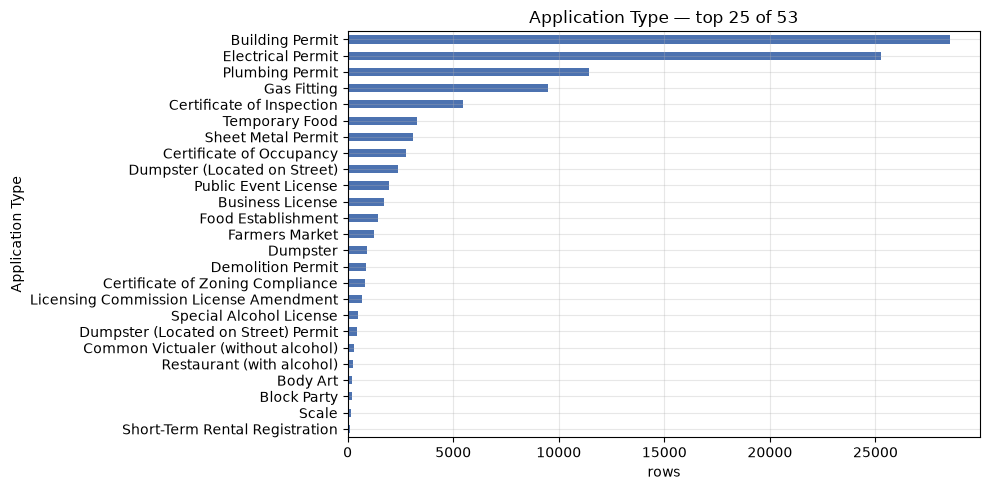

,rows,pct
Application Type,,
Building Permit,28525,27.3
Electrical Permit,25250,24.2
Plumbing Permit,11409,10.9
Gas Fitting,9487,9.1
Certificate of Inspection,5474,5.2
Temporary Food,3308,3.2
Sheet Metal Permit,3101,3.0
Certificate of Occupancy,2783,2.7
Dumpster (Located on Street),2410,2.3


In [4]:
# The full permit/license taxonomy, so we can see our three types in context.
counts = df["Application Type"].value_counts()
ax = counts.head(25).sort_values().plot.barh(color="#4C72B0")
ax.set_title("Application Type — top 25 of %d" % counts.size)
ax.set_xlabel("rows")
plt.tight_layout(); plt.show()

counts.head(12).to_frame("rows").assign(pct=lambda d: (d["rows"] / len(df) * 100).round(1))

The three trade permits we're after are the top of that list. Note the naming quirk: it's
**`Gas Fitting`**, not "Gas Permit" — and each family has a distinct `Application Number` prefix
(`B`, `E`, `G`) which is a handy sanity check that `Application Type` is clean.

In [5]:
TYPES = ["Building Permit", "Electrical Permit", "Gas Fitting"]
COLORS = {"Building Permit": "#4C72B0", "Electrical Permit": "#DD8452", "Gas Fitting": "#55A868"}

trades = df[df["Application Type"].isin(TYPES)].copy()
print(f"{len(trades):,} rows ({len(trades)/len(df):.0%} of file)\n")

# Application Number prefix vs. type — confirms the taxonomy is consistent.
prefix = trades["Application Number"].str.extract(r"^([A-Za-z]+)")[0]
pd.crosstab(trades["Application Type"], prefix)

63,262 rows (61% of file)



,B,E,G
Application Type,,,
Building Permit,28525,0,0
Electrical Permit,0,25250,0
Gas Fitting,0,0,9487


---
# Part A — What kinds of permits are there?

`Application Type` is the family; `Application Subtype` is the real detail, and it means
something *different* in each family:

| Family | What the subtype encodes |
|---|---|
| Building Permit | occupancy class **x** scope of work (`Residential Repair`, `Commercial New Construction`, …) |
| Electrical Permit | occupancy class only (`Residential` / `Commercial`) |
| Gas Fitting | occupancy class **x** new-vs-existing (`Residential - Existing`, `Commercial - New`, …) |

So building permits are the only family where the data itself tells you whether the job was a
repair, a renovation, or new construction.

In [6]:
for t in TYPES:
    sub = trades[trades["Application Type"] == t]
    vc = sub["Application Subtype"].value_counts(dropna=False)
    print(f"===== {t}  (n={len(sub):,}, {vc.notna().sum()} subtypes) =====")
    print(pd.DataFrame({"rows": vc, "pct": (vc / len(sub) * 100).round(1)}).to_string())
    print()

===== Building Permit  (n=28,525, 13 subtypes) =====
                               rows   pct
Application Subtype                      
Residential Repair            12163  42.6
Residential Renovation         4242  14.9
Residential Alteration         3847  13.5
Residential Other              3612  12.7
Commercial Alteration          1165   4.1
Commercial Repair               796   2.8
Commercial Other                719   2.5
Commercial Renovation           585   2.1
Residential New Construction    572   2.0
Residential Addition            563   2.0
Commercial New Construction     213   0.7
Commercial Addition              45   0.2
NaN                               3   0.0

===== Electrical Permit  (n=25,250, 3 subtypes) =====
                      rows   pct
Application Subtype             
Residential          18392  72.8
Commercial            6856  27.2
NaN                      2   0.0

===== Gas Fitting  (n=9,487, 6 subtypes) =====
                        rows   pct
Application Su

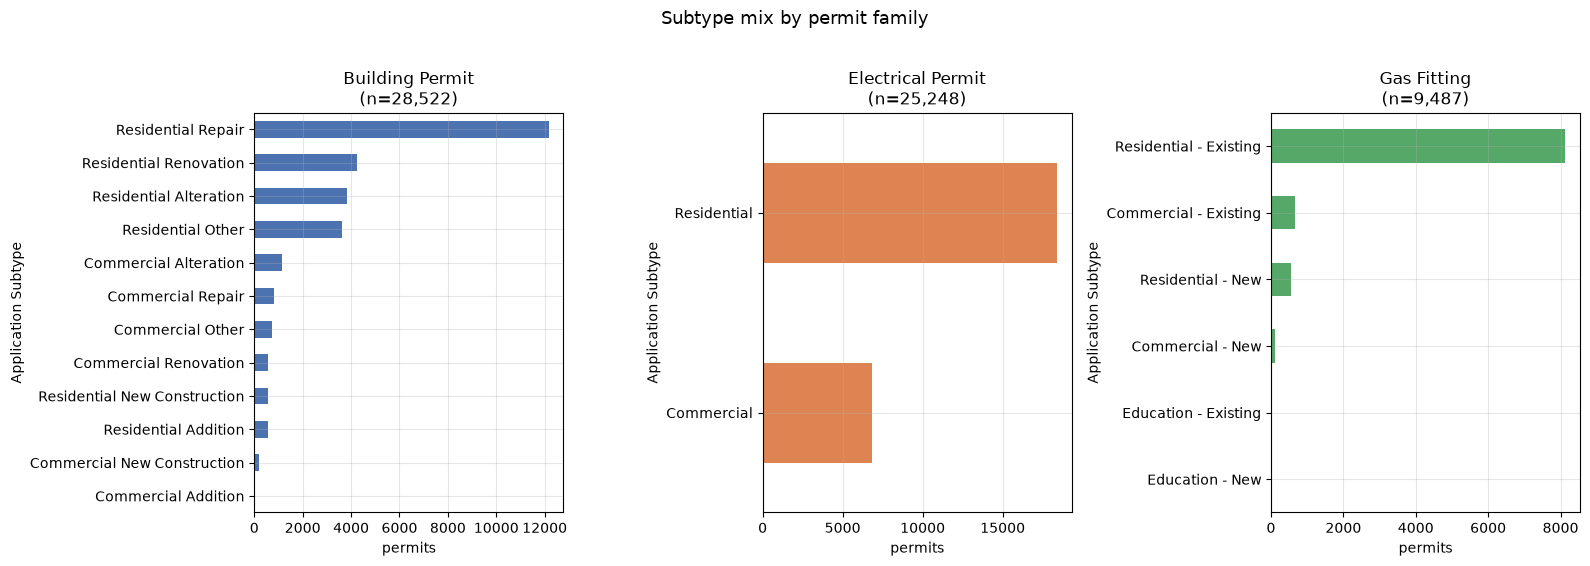

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
for ax, t in zip(axes, TYPES):
    vc = trades.loc[trades["Application Type"] == t, "Application Subtype"].value_counts()
    vc.sort_values().plot.barh(ax=ax, color=COLORS[t])
    ax.set_title(f"{t}\n(n={vc.sum():,})")
    ax.set_xlabel("permits")
fig.suptitle("Subtype mix by permit family", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

### Residential vs. commercial, normalised across families

The subtype strings differ, but all three encode an occupancy class. Parsing it out lets us
compare families directly — Somerville is a dense residential city and the mix reflects that.

Occupancy,Commercial,Education,Residential,Unknown
Application Type,,,,
Building Permit,3523,0,24999,3
Electrical Permit,6856,0,18392,2
Gas Fitting,764,46,8677,0


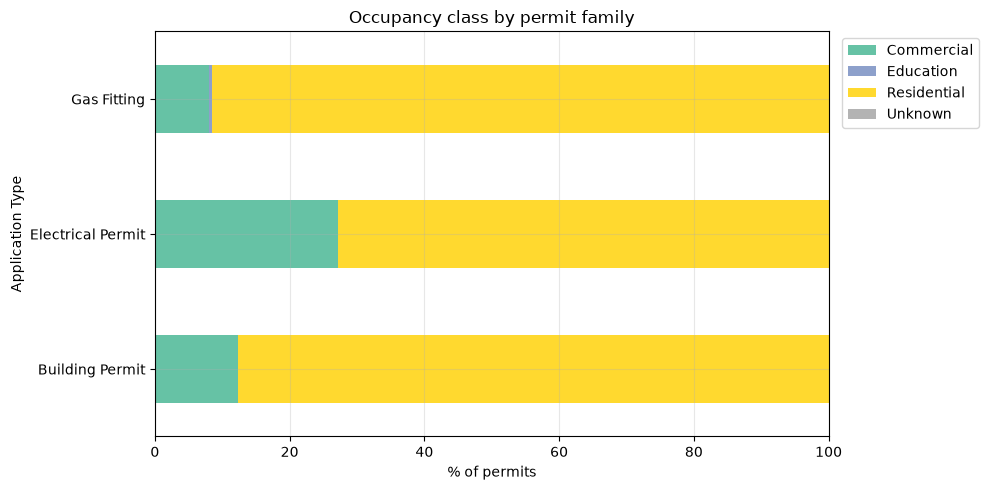

In [8]:
def occupancy(s):
    # Pull Residential / Commercial / Education out of any of the three subtype schemes.
    if pd.isna(s):
        return "Unknown"
    return s.split(" - ")[0].split(" ")[0]


trades["Occupancy"] = trades["Application Subtype"].map(occupancy)

occ = pd.crosstab(trades["Application Type"], trades["Occupancy"])
display(occ)

occ_pct = occ.div(occ.sum(axis=1), axis=0) * 100
ax = occ_pct.plot.barh(stacked=True, colormap="Set2")
ax.set_xlabel("% of permits"); ax.set_title("Occupancy class by permit family")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout(); plt.show()

### Scope of work (building permits only)

In [9]:
bld = trades[trades["Application Type"] == "Building Permit"].copy()
bld["Scope"] = bld["Application Subtype"].str.split(" ", n=1).str[1]

scope = pd.crosstab(bld["Scope"], bld["Occupancy"])
scope["Total"] = scope.sum(axis=1)
display(scope.sort_values("Total", ascending=False))

Occupancy,Commercial,Residential,Total
Scope,,,
Repair,796,12163,12959
Alteration,1165,3847,5012
Renovation,585,4242,4827
Other,719,3612,4331
New Construction,213,572,785
Addition,45,563,608


### Status: where permits end up

The three families behave very differently here, and it matters for any analysis that filters on
status. Electrical permits are almost all `Closed` (the inspection loop completes and the record is
retired). Gas fitting permits mostly sit at `Issued`. Building permits split between the two and
carry the only meaningful volume of `Denied`, `Under Review`, and `Withdrawn` — i.e. **the building
permit is the one with a real review process recorded in this data**.

Status,Closed,Issued,Withdrawn,Denied,Under Review,Approved/Waiting for Payment,Approved,Complete,Expired,Online Application Received,Revoked,Approved/Waiting for Documents,Suspended
Application Type,,,,,,,,,,,,,
Building Permit,11541,12492,1377,1035,1081,460,95,199,152,59,2,30,2
Electrical Permit,21767,1781,1001,386,150,4,74,5,22,28,32,0,0
Gas Fitting,2697,6195,171,77,39,2,174,43,44,45,0,0,0


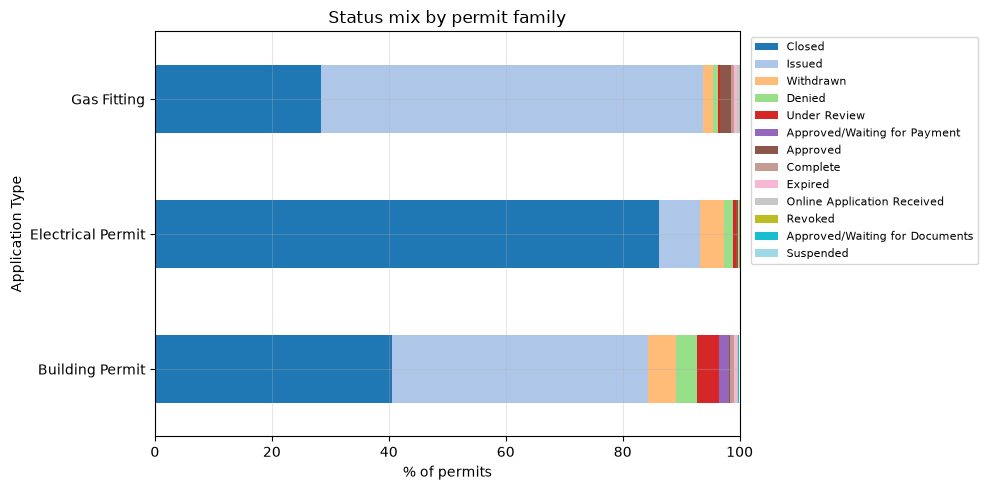

In [10]:
status = pd.crosstab(trades["Application Type"], trades["Status"])
status = status.loc[TYPES, status.sum().sort_values(ascending=False).index]
display(status)

status_pct = (status.div(status.sum(axis=1), axis=0) * 100).round(1)
ax = status_pct.plot.barh(stacked=True, colormap="tab20")
ax.set_xlabel("% of permits"); ax.set_title("Status mix by permit family")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

### Volume over time

Application dates run 2014-02 to the 2026-09 pull date. The final year is partial — don't read the
drop-off as a trend.

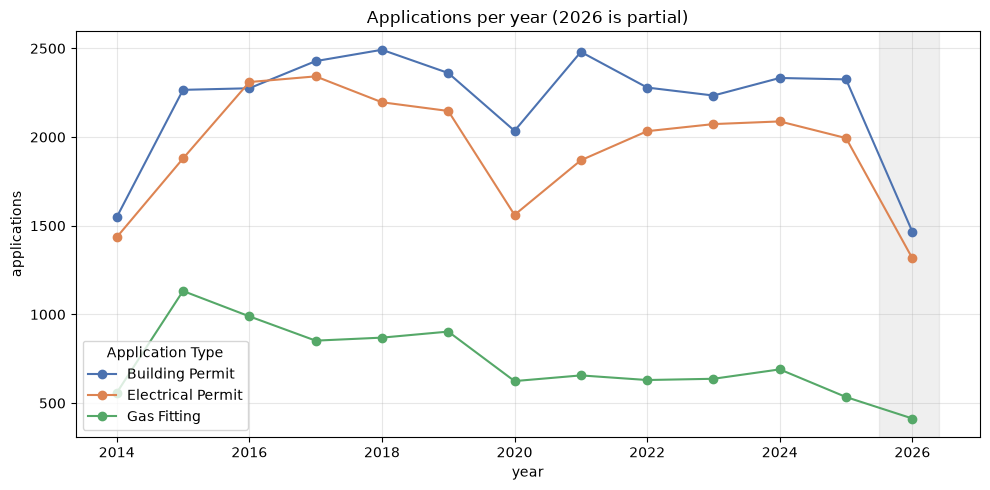

Application Type,Building Permit,Electrical Permit,Gas Fitting
year,,,
2014.0,1548,1435,558
2015.0,2266,1879,1132
2016.0,2275,2310,989
2017.0,2428,2342,852
2018.0,2492,2196,869
2019.0,2361,2147,903
2020.0,2035,1561,624
2021.0,2480,1869,656
2022.0,2279,2033,630


In [11]:
yearly = (trades.assign(year=trades["Application Date"].dt.year)
                .pivot_table(index="year", columns="Application Type",
                             values="Application ID", aggfunc="count"))

ax = yearly[TYPES].plot(marker="o", color=[COLORS[t] for t in TYPES])
ax.set_ylabel("applications"); ax.set_title("Applications per year (2026 is partial)")
ax.axvspan(2025.5, yearly.index.max() + 0.4, color="grey", alpha=0.12)
plt.tight_layout(); plt.show()

yearly[TYPES].astype("Int64")

---
# Part B — What fields are available for each family?

All 51 columns exist for every row, but "exists" is not "populated". The matrix below is the core
answer: **% of rows non-null, per column, per permit family**, next to the file-wide rate.

In [12]:
fill = pd.DataFrame({t: trades.loc[trades["Application Type"] == t, SOURCE_COLS].notna().mean() * 100
                     for t in TYPES})
fill["All rows (file)"] = df[SOURCE_COLS].notna().mean() * 100
fill = fill.round(1)

def shade(v):
    if v == 0:      return "background-color:#f2f2f2;color:#bbb"
    if v < 50:      return "background-color:#fde0dd"
    if v < 95:      return "background-color:#fff7bc"
    return "background-color:#e5f5e0"

fill.style.map(shade, subset=TYPES).format("{:.1f}").set_caption("% of rows populated")

,Building Permit,Electrical Permit,Gas Fitting,All rows (file)
Application ID,100.0,100.0,100.0,100.0
Application Number,100.0,100.0,100.0,100.0
Application Category,100.0,100.0,100.0,100.0
Application Type,100.0,100.0,100.0,100.0
Application Subtype,100.0,100.0,100.0,99.3
Status,100.0,100.0,100.0,100.0
File Number,100.0,100.0,100.0,100.0
Department,100.0,100.0,100.0,100.0
Project Description or Business Name,100.0,100.0,100.0,99.9
Application Date,100.0,100.0,100.0,87.9


### Reading the matrix: four groups of columns

Rather than eyeball 51 rows, bucket them by how they behave across the three families.

In [13]:
core   = fill[(fill[TYPES] >= 99).all(axis=1)].index.tolist()
absent = fill[(fill[TYPES] == 0).all(axis=1)].index.tolist()
differs = fill[(fill[TYPES].max(axis=1) - fill[TYPES].min(axis=1)) > 25].index.tolist()
partial = [c for c in fill.index if c not in core + absent + differs]

for label, cols in [("ALWAYS PRESENT (>=99% in all three)", core),
                    ("NEVER PRESENT (0% in all three)", absent),
                    ("DIFFERS SHARPLY BETWEEN FAMILIES (>25pt spread)", differs),
                    ("PARTIAL / MIXED", partial)]:
    print(f"----- {label}: {len(cols)} columns -----")
    for c in cols:
        print(f"   {c:<40} " + "  ".join(f"{t.split()[0][:5]}={fill.loc[c, t]:>5.1f}" for t in TYPES))
    print()

----- ALWAYS PRESENT (>=99% in all three): 33 columns -----
   Application ID                           Build=100.0  Elect=100.0  Gas=100.0
   Application Number                       Build=100.0  Elect=100.0  Gas=100.0
   Application Category                     Build=100.0  Elect=100.0  Gas=100.0
   Application Type                         Build=100.0  Elect=100.0  Gas=100.0
   Application Subtype                      Build=100.0  Elect=100.0  Gas=100.0
   Status                                   Build=100.0  Elect=100.0  Gas=100.0
   File Number                              Build=100.0  Elect=100.0  Gas=100.0
   Department                               Build=100.0  Elect=100.0  Gas=100.0
   Project Description or Business Name     Build=100.0  Elect=100.0  Gas=100.0
   Application Date                         Build=100.0  Elect=100.0  Gas=100.0
   Application Amount                       Build=100.0  Elect=100.0  Gas=100.0
   Amount Paid                              Build=100.0  Ele

### The columns that actually distinguish the three families

Three findings worth carrying into any downstream work:

1. **`Estimated Construction Cost` is never recorded for gas fitting permits** (0%), but is
   present on 100% of building and electrical permits. Any cost-of-work analysis silently drops
   gas work.
2. **`Contractor Company Name` / `Contractor Name` are likewise empty for every gas permit.**
   The only party recorded on a gas permit is `Applicant Company Name` (the gas fitter, ~97%).
   For building permits the applicant/contractor pair is populated ~91%/99%.
3. **`Close Date` coverage is wildly uneven** — 92% electrical, 51% building, 34% gas — which
   tracks the status mix above. Duration-to-close is only really computable for electrical.

The nine `Closing at 2 AM Weekends` … `Public Patio Entertainment Performers` columns are
liquor/entertainment license attributes and are empty for all construction permits.

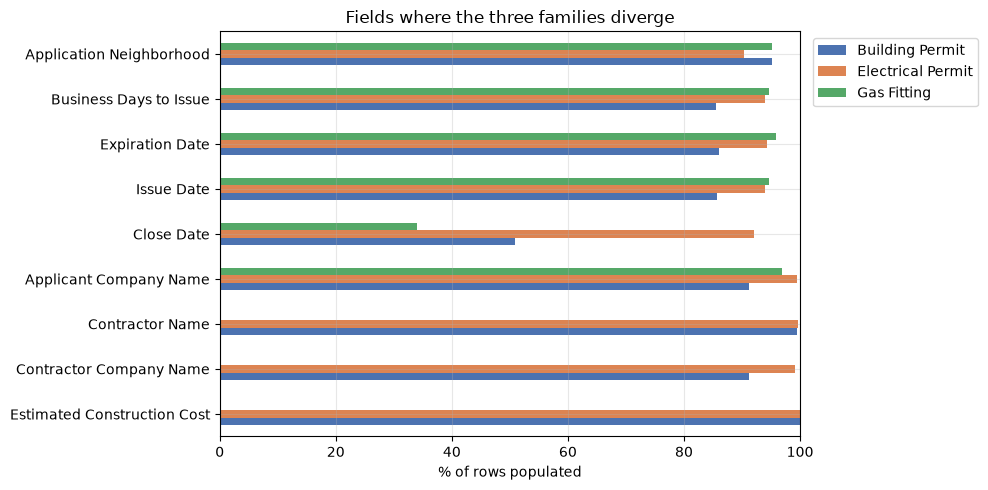

In [14]:
SPOTLIGHT = ["Estimated Construction Cost", "Contractor Company Name", "Contractor Name",
             "Applicant Company Name", "Close Date", "Issue Date", "Expiration Date",
             "Business Days to Issue", "Application Neighborhood"]

ax = fill.loc[SPOTLIGHT, TYPES].plot.barh(color=[COLORS[t] for t in TYPES])
ax.set_xlabel("% of rows populated"); ax.set_xlim(0, 100)
ax.set_title("Fields where the three families diverge")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout(); plt.show()

### Per-family data dictionary

For each family: every column, its dtype, fill rate, cardinality, and a couple of real values.
This is the reference table to come back to when you're deciding what's usable.

In [15]:
def dictionary(name, max_examples=2, hide_empty=True):
    sub = trades.loc[trades["Application Type"] == name, SOURCE_COLS]
    rows = []
    for c in SOURCE_COLS:
        s = sub[c]
        nn = s.dropna()
        if hide_empty and nn.empty:
            continue
        ex = nn.unique()[:max_examples]
        rows.append({
            "column": c,
            "dtype": str(s.dtype),
            "%filled": round(s.notna().mean() * 100, 1),
            "n_unique": int(nn.nunique()),
            "examples": " | ".join(str(v)[:45] for v in ex),
        })
    out = pd.DataFrame(rows).set_index("column")
    out.columns.name = f"{name}  (n={len(sub):,}; {len(sub.columns) - len(out)} all-null columns hidden)"
    return out


dictionary("Building Permit")

"Building Permit (n=28,525; 9 all-null columns hidden)",dtype,%filled,n_unique,examples
column,,,,
Application ID,str,100.0,28525,1887292 | 1887293
Application Number,str,100.0,28525,B14-001250 | B14-001251
Application Category,str,100.0,1,Permitting
Application Type,str,100.0,1,Building Permit
Application Subtype,str,100.0,12,Residential Other | Residential Repair
Status,str,100.0,13,Issued | Withdrawn
File Number,str,100.0,28112,14-008175 | 14-008176
Department,str,100.0,1,ISD Building
Project Description or Business Name,str,100.0,25480,"Replace decking boards on existing deck. Exte | new rubber roof,new window,..."


In [16]:
dictionary("Electrical Permit")

"Electrical Permit (n=25,250; 9 all-null columns hidden)",dtype,%filled,n_unique,examples
column,,,,
Application ID,str,100.0,25250,1887243 | 1887258
Application Number,str,100.0,25250,E14-001179 | E14-001180
Application Category,str,100.0,1,Permitting
Application Type,str,100.0,1,Electrical Permit
Application Subtype,str,100.0,2,Residential | Commercial
Status,str,100.0,11,Closed | Denied
File Number,str,100.0,24625,14-008170 | 14-008171
Department,str,100.0,1,ISD Building
Project Description or Business Name,str,100.0,22604,wire bathrooms | Installing 24 PV solar panels on roof. 5.98KW


In [17]:
dictionary("Gas Fitting")

"Gas Fitting (n=9,487; 12 all-null columns hidden)",dtype,%filled,n_unique,examples
column,,,,
Application ID,str,100.0,9487,1887274 | 1921754
Application Number,str,100.0,9487,G14-000428 | G14-000458
Application Category,str,100.0,1,Permitting
Application Type,str,100.0,1,Gas Fitting
Application Subtype,str,100.0,6,Commercial - Existing | Residential - Existing
Status,str,100.0,10,Issued | Closed
File Number,str,100.0,9284,14-008173 | 14-008466
Department,str,100.0,1,ISD Building
Project Description or Business Name,str,100.0,6645,"remove infared heater and install 150,000 btu | 58,000 BTU Hot Air Furnace a..."


### Which columns are usable as *categoricals*?

Low-cardinality columns are the ones you can group by. Everything else is free text, an
identifier, or a measurement.

In [18]:
from pandas.api.types import is_numeric_dtype, is_datetime64_any_dtype

cat_candidates = []
for c in SOURCE_COLS:
    if is_numeric_dtype(trades[c]) or is_datetime64_any_dtype(trades[c]):
        continue  # measurements and dates, not categories
    nn = trades[c].dropna()
    if nn.empty or nn.nunique() > 30:
        continue
    cat_candidates.append({"column": c, "n_unique": int(nn.nunique()),
                           "values": ", ".join(sorted(map(str, nn.unique()))[:8])})
pd.DataFrame(cat_candidates).set_index("column")

,n_unique,values
column,,
Application Category,1,Permitting
Application Type,3,"Building Permit, Electrical Permit, Gas Fitting"
Application Subtype,20,"Commercial, Commercial - Existing, Commercial - New, Commercial Addition, Co..."
Status,13,"Approved, Approved/Waiting for Documents, Approved/Waiting for Payment, Clos..."
Department,1,ISD Building
Application Ward,7,"1, 2, 3, 4, 5, 6, 7"
Application Precinct,28,"1-1, 1-2, 1-3, 1-4, 2-1, 2-2, 2-3, 2-4"
Application Neighborhood,18,"Assembly Square, Ball Square, Boynton Yards, Brickbottom, Davis Square, Duck..."


---
## Part C — A few things the fields let you do

Quick passes at the analyses the populated fields actually support, to show what's there.

### Reported construction cost (building + electrical only)

Heavily right-skewed with a long tail and a floor of small jobs, so log scale.

Cost is **self-reported on the application and not validated**, and it shows: the electrical
maximum is ~$2.1 *trillion*, and there are `$1` entries at the other end. Use medians, and clip
or winsorize before doing anything with the mean.

                     count        mean           std  min     25%      50%      75%       95%           max
Application Type                                                                                           
Building Permit    28045.0    232726.0  4.335204e+06  1.0  7000.0  15950.0  40000.0  368225.0  2.940000e+08
Electrical Permit  25055.0  85282184.0  1.349370e+10  1.0  1000.0   3000.0  10000.0   50000.0  2.135888e+12


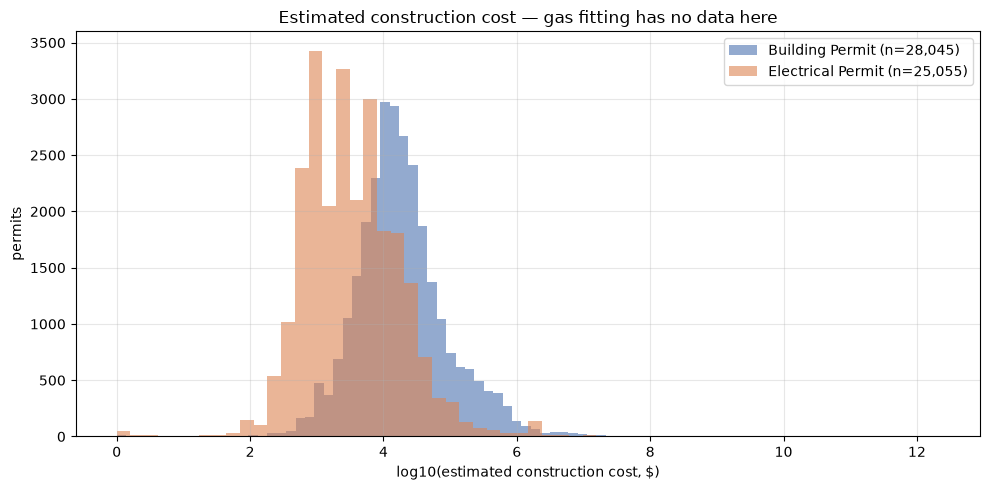

In [19]:
cost = trades[trades["Estimated Construction Cost"].notna() &
              (trades["Estimated Construction Cost"] > 0)]

print(cost.groupby("Application Type")["Estimated Construction Cost"]
          .describe(percentiles=[.25, .5, .75, .95]).round(0).to_string())

fig, ax = plt.subplots()
for t in ["Building Permit", "Electrical Permit"]:
    v = cost.loc[cost["Application Type"] == t, "Estimated Construction Cost"]
    ax.hist(np.log10(v), bins=60, alpha=0.6, label=f"{t} (n={len(v):,})", color=COLORS[t])
ax.set_xlabel("log10(estimated construction cost, $)"); ax.set_ylabel("permits")
ax.set_title("Estimated construction cost — gas fitting has no data here")
ax.legend(); plt.tight_layout(); plt.show()

### Time from application to issue

`Business Days to Issue` is pre-computed by the city. It is *not* clean — some values are in the
thousands, which is a multi-year gap, likely reflecting renewals or backdated records rather than
review time. The median is the number to trust.

                     count  mean   std  min   50%   90%    99%     max
Application Type                                                      
Building Permit    24431.0  28.9  66.0  0.0  13.0  60.0  267.0  1730.0
Electrical Permit  23712.0  12.6  39.7  0.0   4.0  28.0  151.0  2795.0
Gas Fitting         8980.0   9.6  40.1  0.0   2.0  14.0  128.2  1289.0


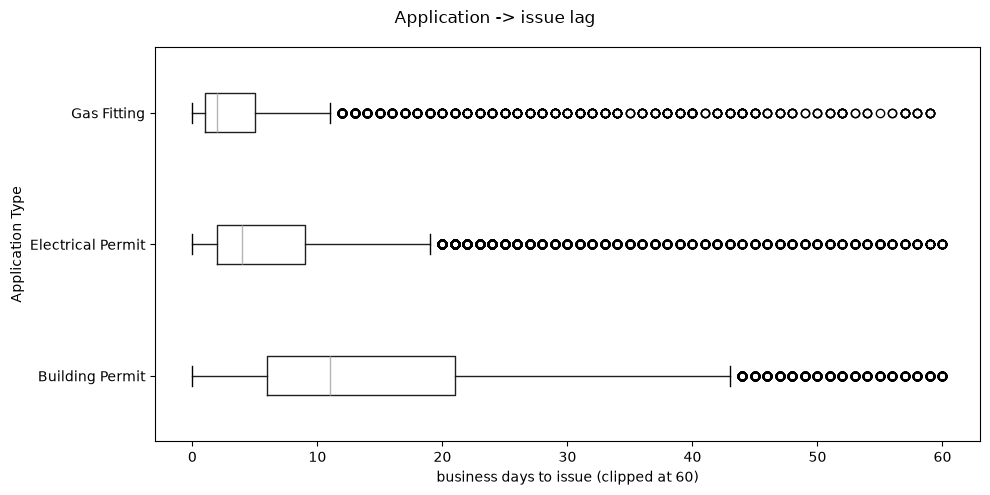

In [20]:
btd = trades[trades["Business Days to Issue"].notna()]
print(btd.groupby("Application Type")["Business Days to Issue"]
         .describe(percentiles=[.5, .9, .99]).round(1).to_string())

ax = btd[btd["Business Days to Issue"].between(0, 60)].boxplot(
    column="Business Days to Issue", by="Application Type", vert=False, grid=False)
ax.set_xlabel("business days to issue (clipped at 60)"); ax.set_title("")
plt.suptitle("Application -> issue lag"); plt.tight_layout(); plt.show()

### Days to issue — residential only

Residential is the bulk of every family (74% / 73% / 86%), so isolating it strips out the
commercial jobs that skew the tails and makes the three families directly comparable. Three views:
the distribution per family, the gradient by scope of work, and how the median has moved year over
year.

In [21]:
resi = trades[(trades["Occupancy"] == "Residential") & trades["Business Days to Issue"].notna()].copy()
print(f"{len(resi):,} residential permits with a days-to-issue value\n")

print(resi.groupby("Application Type")["Business Days to Issue"]
          .describe(percentiles=[.25, .5, .75, .9]).round(1).to_string())

46,955 residential permits with a days-to-issue value

                     count  mean   std  min  25%   50%   75%   90%     max
Application Type                                                          
Building Permit    21492.0  27.9  67.1  0.0  6.0  12.0  25.0  57.0  1730.0
Electrical Permit  17250.0  11.7  32.6  0.0  2.0   4.0  11.0  28.0  2795.0
Gas Fitting         8213.0   9.9  41.6  0.0  1.0   2.0   5.0  15.0  1289.0


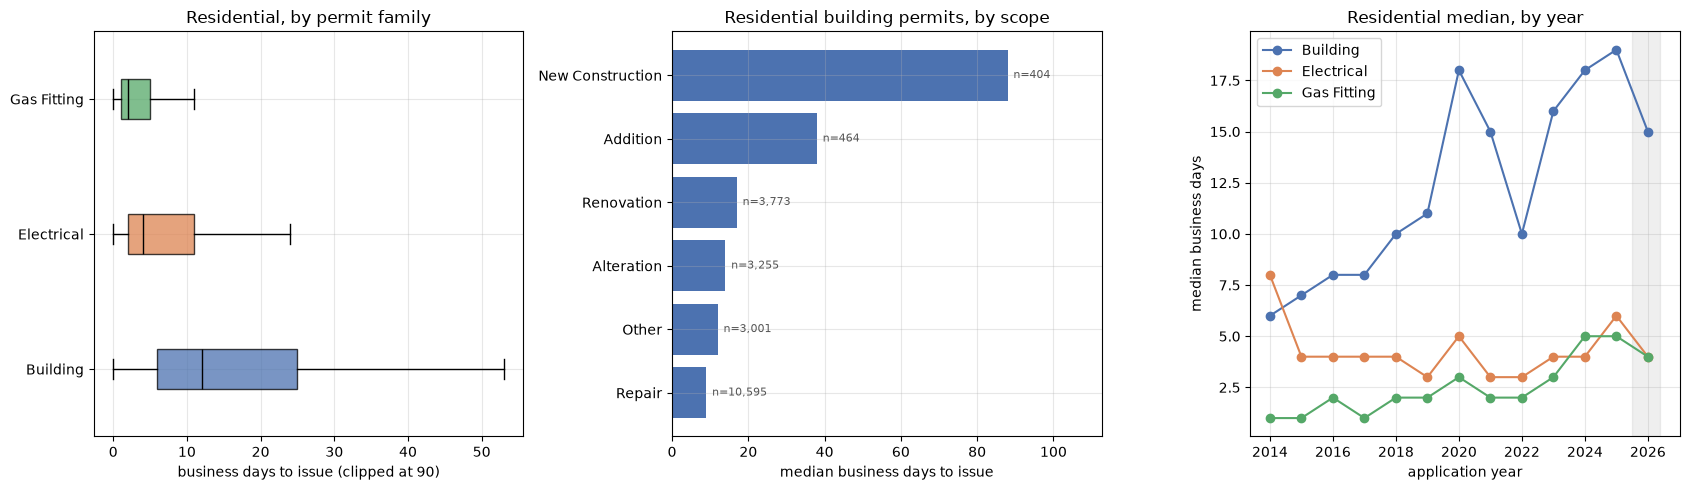

,median_days,permits
Scope,,
Repair,9.0,10595
Other,12.0,3001
Alteration,14.0,3255
Renovation,17.0,3773
Addition,38.0,464
New Construction,88.0,404


Application Type,Building Permit,Electrical Permit,Gas Fitting
Application Date,,,
2014,6.0,8.0,1.0
2015,7.0,4.0,1.0
2016,8.0,4.0,2.0
2017,8.0,4.0,1.0
2018,10.0,4.0,2.0
2019,11.0,3.0,2.0
2020,18.0,5.0,3.0
2021,15.0,3.0,2.0
2022,10.0,3.0,2.0


In [22]:
resi_bld = resi[resi["Application Type"] == "Building Permit"].copy()
resi_bld["Scope"] = resi_bld["Application Subtype"].str.split(" ", n=1).str[1]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1. distribution by family
data = [resi.loc[resi["Application Type"] == t, "Business Days to Issue"].clip(upper=90) for t in TYPES]
bp = axes[0].boxplot(data, orientation="horizontal", patch_artist=True, showfliers=False,
                     tick_labels=[t.replace(" Permit", "") for t in TYPES])
for patch, t in zip(bp["boxes"], TYPES):
    patch.set_facecolor(COLORS[t]); patch.set_alpha(0.75)
for med in bp["medians"]:
    med.set_color("black")
axes[0].set_xlabel("business days to issue (clipped at 90)")
axes[0].set_title("Residential, by permit family")

# 2. scope gradient (building permits only carry scope)
scope_med = resi_bld.groupby("Scope")["Business Days to Issue"].median().sort_values()
scope_n = resi_bld.groupby("Scope").size()
bars = axes[1].barh(scope_med.index, scope_med.values, color=COLORS["Building Permit"])
for bar, sc in zip(bars, scope_med.index):
    axes[1].text(bar.get_width() + 1.5, bar.get_y() + bar.get_height() / 2,
                 f"n={scope_n[sc]:,}", va="center", fontsize=8, color="#555")
axes[1].set_xlim(0, scope_med.max() * 1.28)
axes[1].set_xlabel("median business days to issue")
axes[1].set_title("Residential building permits, by scope")

# 3. trend
yearly_med = resi.pivot_table(index=resi["Application Date"].dt.year,
                              columns="Application Type",
                              values="Business Days to Issue", aggfunc="median")
for t in TYPES:
    axes[2].plot(yearly_med.index, yearly_med[t], marker="o", label=t.replace(" Permit", ""),
                 color=COLORS[t])
axes[2].set_xlabel("application year"); axes[2].set_ylabel("median business days")
axes[2].set_title("Residential median, by year"); axes[2].legend()
axes[2].axvspan(2025.5, yearly_med.index.max() + 0.4, color="grey", alpha=0.12)

plt.tight_layout(); plt.show()

display(scope_med.rename("median_days").to_frame().assign(permits=scope_n).sort_values("median_days"))
yearly_med[TYPES].round(1)

Two things stand out:

- **Scope drives the wait, not much else.** A residential repair clears in a median of 9 business
  days; a residential addition takes 38 and new construction 88 — roughly a 10x spread within the
  same permit family. Electrical (median 4) and gas (median 2) are effectively over-the-counter.
- **Residential building permits have slowed.** The median has climbed from ~6 business days in
  2014 to ~19 in 2025, with a bump in 2020. Electrical and gas have stayed roughly flat over the
  same period, so this is specific to building review rather than a city-wide backlog. (2026 is
  partial, and later-filed slow permits may not have issued yet — recent years skew fast.)

### Geography

Lat/lon, ward, precinct, neighborhood and assessor parcel number are populated for ~99% of trade
permits — this is the join key into `data/ma/somerville/parcels_gdb/` and the basis for any
spatial work.

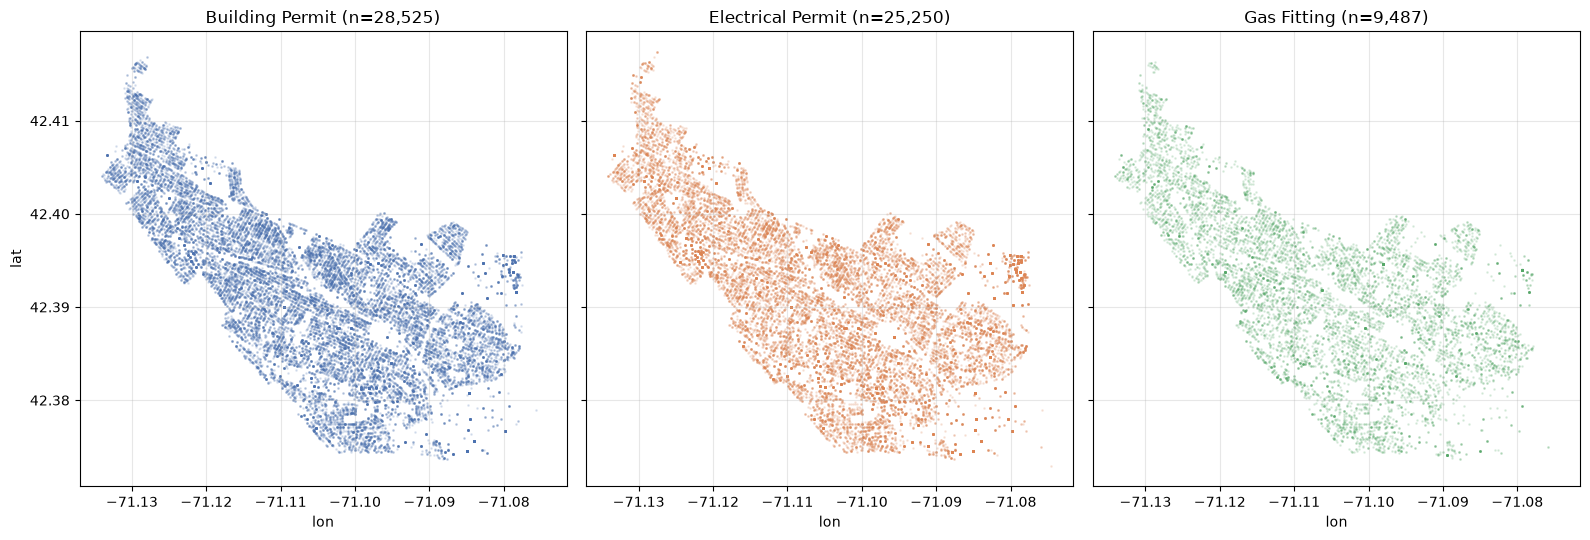

Application Type,Building Permit,Electrical Permit,Gas Fitting
Application Ward,,,
1,3891,4724,1270
2,3628,3794,1356
3,4332,3642,1310
4,3533,2691,1202
5,4801,3624,1503
6,4591,3815,1535
7,3714,2903,1291


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharex=True, sharey=True)
for ax, t in zip(axes, TYPES):
    s = trades[trades["Application Type"] == t]
    ax.scatter(s["Application Longitude"], s["Application Latitude"],
               s=1, alpha=0.15, color=COLORS[t])
    ax.set_title(f"{t} (n={len(s):,})"); ax.set_xlabel("lon")
axes[0].set_ylabel("lat")
plt.tight_layout(); plt.show()

pd.crosstab(trades["Application Ward"], trades["Application Type"])[TYPES]

---
## Summary

**a) Permit kinds**

| Family | Rows | Subtype scheme | Subtypes |
|---|---:|---|---|
| `Building Permit` | 28,525 | occupancy x scope | 12 — Residential/Commercial x Repair, Renovation, Alteration, Addition, New Construction, Other |
| `Electrical Permit` | 25,250 | occupancy only | 2 — Residential, Commercial |
| `Gas Fitting` | 9,487 | occupancy x new/existing | 6 — Residential/Commercial/Education x New, Existing |

Building permits are ~74% residential and dominated by `Residential Repair` (12,163, 43% of all
building permits). Electrical is 73% residential. Gas fitting is 86% `Residential - Existing`
(i.e. replacing equipment in existing housing stock) and is the only family with an
`Education` occupancy class.

**b) Fields**

- **33 of the 51 columns are reliably populated for all three** (>=99%) — IDs, type/subtype, status, dates,
  fee amounts, address, parcel number, lat/lon, ward/precinct/neighborhood, and the
  `Active in 20XX` flags.
- **Gas fitting is the sparsest family**: no `Estimated Construction Cost`, no contractor columns
  at all. Only `Applicant Company Name` identifies who did the work.
- **Only building permits record scope of work** and only they carry meaningful
  `Denied` / `Under Review` / `Withdrawn` volume.
- **`Close Date` is unreliable outside electrical** (92% vs 51% building, 34% gas).
- **9 columns are liquor/entertainment license attributes** and are always empty here.

**Caveats to carry forward**

- 2026 is partial (pull date 2026-09-05); `Issue Date` extends to 2026-11-12 for future-dated
  license periods.
- `Estimated Construction Cost` is applicant-reported and unvalidated — it contains
  implausible extremes (max ~$2.1e12 on an electrical permit). Filter before use.
- `Business Days to Issue` has multi-thousand-day outliers; prefer medians.
- Rows are applications, not one-per-project — a single job produces separate B/E/G/P permits;
  join on `Assessor's Parcel Number` + date window to reassemble.